<a href="https://colab.research.google.com/github/sumairanooruddin786-droid/House-Price-Prediction/blob/main/dog_vs_cat_clasification_class_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import numpy as np

In [26]:
(train_data, val_data), dataset_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    as_supervised=True,
    with_info=True)

print("Classes:", dataset_info.features['label'].names)

Classes: ['cat', 'dog']


In [27]:
def preprocess_image(image, label):
    image = tf.image.resize(image, [128, 128])
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

IMG_SIZE = 128
BATCH_SIZE = 32

train_dataset = train_data.map(preprocess_image).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_dataset = val_data.map(preprocess_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [28]:
model = tf.keras.models.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(2,2),


    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),


    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),

    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,329 (49.36 MB)

 Trainable params: 12,939,329 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset
)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step - accuracy: 0.6795 - loss: 0.5884 - val_accuracy: 0.7700 - val_loss: 0.4789
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - accuracy: 0.7810 - loss: 0.4569 - val_accuracy: 0.8012 - val_loss: 0.4391
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.8296 - loss: 0.3772 - val_accuracy: 0.8102 - val_loss: 0.4238
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - accuracy: 0.8662 - loss: 0.3062 - val_accuracy: 0.8265 - val_loss: 0.4238
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 30s 50ms/step - accuracy: 0.9140 - loss: 0.2135 - val_accuracy: 0.8293 - val_loss: 0.4692


In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_animal(image_path, trained_model):
    # 1. Image ko read karna (OpenCV BGR format me read karta hai)
    img = cv2.imread(image_path)

    # OpenCV BGR ko RGB me convert karna zaroori hai
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Image ko 128x128 par resize karna (jo humare model ka input size tha)
    img_resized = cv2.resize(img_rgb, (128, 128))

    # 3. Normalize karna (0 se 1 ke darmiyan values lana)
    img_normalized = img_resized / 255.0

    # 4. Batch dimension add karna (1, 128, 128, 3)
    # Keras ko batana padta hai ke yeh 1 image ka batch hai
    img_input = np.expand_dims(img_normalized, axis=0)

    # 5. Model se prediction lena
    prediction = trained_model.predict(img_input)

    # Kyunki output me 'sigmoid' functional layer hai, value 0 aur 1 ke darmiyan hogi
    score = prediction[0][0]

    # 6. Result display karna
    plt.imshow(img_rgb)
    plt.axis('off')

    if score > 0.5:
        # Score 1 ke jitna qareeb hoga, utna zyada confirm Dog hoga
        confidence = score * 100
        plt.title(f"Prediction: DOG ({confidence:.2f}%)")
    else:
        # Score 0 ke jitna qareeb hoga, utna zyada confirm Cat hogi
        confidence = (1 - score) * 100
        plt.title(f"Prediction: CAT ({confidence:.2f}%)")

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step


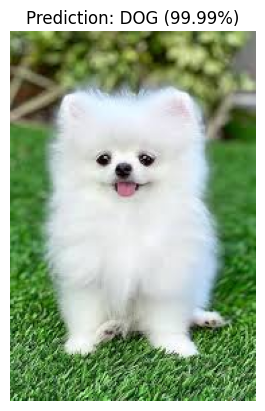

In [31]:
my_image_path = '/content/test_dog_image.jfif'

# Function ko call karen (is me aap ka trained model pass hoga)
# Add a check to see if the image was loaded successfully
img = cv2.imread(my_image_path)
if img is None:
    print(f"Error: Image not found at {my_image_path}. Please upload the image or provide a valid path.")
else:
    predict_animal(my_image_path, model)